In [1]:
import pandas as pd
import numpy as np
import re

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv(r"D:\DATA SCIENTIST\6- PROJECTS\1- Real Estate CAPSTONE PROJECT\CODE\1- WebScrapping\2- independent-house - independent-house.csv")

In [4]:
df.drop(columns='area', inplace=True)

In [5]:
df.rename(columns={'rate': 'area'}, inplace=True)

In [6]:
df.shape

(1036, 20)

### datacleaning dropping link column

In [7]:
df.drop(columns='link', inplace=True)

### adding new column to differentiate between flats and individual homes

In [8]:
flat = 'house'

In [9]:
df.insert(0, 'type', flat)

### cleaning dataset

In [10]:
df = df[df['property_name'] != 'property_name']

### filling missing values with 'independent'

In [11]:
df['society'].fillna('independent', inplace=True)

### new column name bhk

In [12]:
bhk = df['property_name'].str.split(' Bedroom House for sale in ').str.get(0).str.strip()

In [13]:
df.insert(1, 'bhk', bhk)

### adding new column name sector

In [14]:
list = df['property_name'].str.split(' Bedroom House for sale in ').str.get(1).str.strip().apply(lambda x: x.split()[1] if 'Gurgaon' in x else x)

In [15]:
list = list.replace({'A Block Sushant Lok Phase 1': '28', 'Acharya Puri': '12', 'Anand Garden, Sector-105': '105', 'Ansal Plaza': '23',
                    'Arjun Nagar':'8', 'anand garden, sector-105 gurgaon':'105', 'West Rajiv Nagar': '12', 'Vishnu Garden': '105',
                    'Uppals Southend': '49', 'Sushant Lok Phase 3': '57','Sushant Lok Phase 2':'57','Sushant Lok Phase 1':'43',
                    'Surya Vihar':'9','Surat Nagar Phase 2':'104','Surat Nagar 1':'104','Surat Nagar':'104','Suncity':'54','Subhash Nagar':'12',
                    'South City 1':'41','South City':'41','Sohna Road':'33', 'Sohna':'33','Shivpuri':'7'})

In [16]:
list = list.replace({'sector-5 sheetla colony':'5','ravi nager basai road':'9','near nand hospital':np.NaN,'laxmna vihar, phase 2':'3',
                    'devi lal colony gali no 12 gurgaon nr omkar public school':'9','Vir Nagar':'8','Shivaji Nagar':'11','Sheetla Colony':'5',
                    'C Block Sushant Lok Phase 1':'43','DLF Phase 1':'26','DLF Phase 2':'25','DLF Phase 3':'24','DLF Phase 4':'27','DLF Phase 5':'43'})

In [17]:
list = list.replace({'Ashok Vihar':'3','Ashok Vihar Phase 2':'Ashok Vihar Phase 3 Extension','Ashok Vihar Phase 3':'Ashok Vihar Phase 3 Extension',
                    'B Block Sushant Lok Phase 1':'43','Baldev Nagar':'7','Bhim Nagar':'6','Dayanand Colony':'6','Devilal Colony':'9','Gandhi Nagar':'11',
                    'Greenwood City':'45','Hira Nagar':'11','Jacobpura':'12','Jacobpura Near Sadar Bazar':'12','Jyoti Park':'7','Laxman Vihar':'3A',
                     'Laxmi Garden':'11','Madanpuri':'7','Malibu Town':'47','Mianwali Colony':'12'})

In [18]:
list = list.replace({'Palam Vihar':'2','Rajendra Park':'105','Rajiv Nagar':'105','Sector-33 Sohna':'33','Sector 36 Sohna':'33','Saraswati Vihar':'28',
    'Rajendra Park':'105','Patel Nagar':'15','New Colony':'7','Nirvana Country':'50','Laxman Vihar Phase 2':'3A','New Palam Vihar Phase 1':'110',
                     'New Palam Vihar Phase 2':'110','Sector 15 Part 2':'15','Sector 15 Part 1':'15','Shakti Nagar':'11','Ravi Nagar':'9',
                     'Krishna Colony':'7','Manohar Nagar':'8','New Basti':'8','Ravi Nagar':'9','Prem Nagar':'13','Ram Nagar':'8','Rajiv Chowk':'33',
                     'New Palam Vihar':'110','Pratap Nagar':'8','Rosewood':'49','Mayfield Garden':'50'
})

In [19]:
list = list.replace({'Sector 1 Imt Manesar': '1', 'New Palam Vihar': '110', 'Sector 1A IMT Manesar':'1A', 'Palam Vihar': '2', 'Adarsh Nagar': np.NaN,
                        'Ashok Vihar Phase 2': np.NaN, 'Ashok Vihar': np.NaN, 'Ashok Vihar Phase 3 Extension': np.NaN, 'Chakkarpur': '28',
                        'DLF Phase 2': '25', 'DLF Phase 3': '24', 'DLF Phase 4': '27', 'DLF Phase 5': '43', 'Nirvana Country': '50', 'Sector-33 Sohna': '33', 'Sohna': '33'})

In [20]:
exclude_list = list.value_counts().sort_values().sort_index().iloc[87:].drop(['Palam Vihar Extension']).index.tolist()

In [21]:
exclude_index = list[list.isin(exclude_list)].index.tolist()

In [22]:
df = df.drop(index=exclude_index)

In [23]:
list.drop(index=exclude_index, inplace=True)

In [24]:
df.insert(2, 'sector', list)

### datacleaning - sector column

In [25]:
df.dropna(subset='sector', inplace=True)

### datacleaning dropping property name column

In [26]:
df.drop(columns='property_name', inplace=True)

### datacleaning society name column

In [27]:
df['society'] = df['society'].str.replace(r'\d+(\.\d+)? ★', '', regex=True).str.lower()

### datacleaning and feature engineering of price column

In [28]:
df['price'] = df['price'].apply(lambda x: float(x.split()[0])/100 if 'Lac' in str(x) else str(x).split()[0])

In [29]:
df = df[df['price'] != 'Price']

In [30]:
df['price'] = df['price'].replace('NA', np.NaN).astype('float')

###  datacleaning beadroom column

In [31]:
df['bedroom'] = df['bedroom'].str.split().str.get(0).str.strip().astype('float')

###  datacleaning bathroom column

In [32]:
df['bathroom'] = df['bathroom'].str.split().str.get(0).str.strip().astype('float')

###  datacleaning balcony column

In [33]:
df['balcony'] = df['balcony'].str.split().str.get(0).str.strip().replace({'3+': '4', 'No': '0'}).astype('float')

### feature engineering on additional room column

In [34]:
df['additionalRoom'] = df['additionalRoom'].fillna('NA')
cols = ['Servant Room', 'Store Room', 'Pooja Room', 'Study Room', 'Others']
# df['additionalRoom'].value_counts()
for col in cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [35]:
df.drop(columns='additionalRoom', inplace=True)

### datacleaning dropping address column

In [36]:
df.drop(columns='address', inplace=True)

### feature engineering on area_sqft column from area column

In [37]:
price_sqft = df['area'].str.extract(r'(\d+,\d+)')[0].str.replace(',', '').astype('float')

In [38]:
df.insert(5, 'price_sqft',price_sqft)

In [39]:
df.drop(columns='area', inplace=True)

### feature engineering on noOfFloor column

In [40]:
floor = df['noOfFloor'].str.split().str.get(0).str.strip().astype('float')
df.insert(13, 'floor', floor)

In [41]:
df.drop(columns='noOfFloor',inplace=True)

### feature engineering on facing column

In [42]:
df['facing'] = df['facing'].fillna('NA')

<Axes: ylabel='count'>

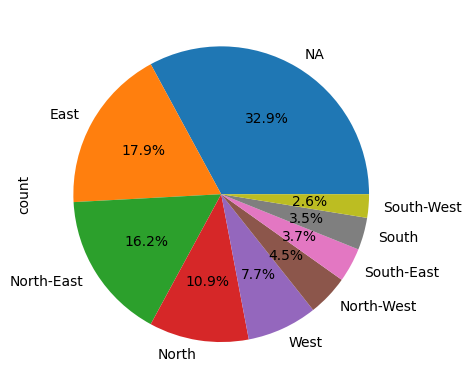

In [43]:
df['facing'].value_counts().plot(kind='pie', autopct='%0.1f%%')

### feature enginnering on age prossession column

In [44]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [45]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [46]:
df['agePossession'].value_counts()

agePossession
Moderately Old        239
Relatively New        210
Old Property          197
Undefined             178
New Property          108
Under Construction      4
Name: count, dtype: int64

### feature engineering on areawithtype 3 new columns

In [47]:
plot_area_pattern = r'Plot area (\d+)(\(\d+\.\d+ sq\.m\.\))?'
carpet_area_pattern = r'Carpet area: (\d+) \((\d+\.\d+) sq\.m\.\)'
built_up_area_pattern = r'Built Up area: (\d+) \((\d+\.\d+) sq\.m\.\)'

def get_areas(description):
    description = str(description)  # Convert to string to handle non-string values
    plot_match = re.search(plot_area_pattern, description)
    plot_area = float(plot_match.group(1)) if plot_match else np.NaN

    carpet_match = re.search(carpet_area_pattern, description)
    carpet_area = float(carpet_match.group(1)) if carpet_match else 'NA'
    
    built_up_match = re.search(built_up_area_pattern, description)
    build_area = float(built_up_match.group(1)) if built_up_match else 'NA'

    return plot_area, build_area, carpet_area

df[['plot_area', 'carpet_area', 'build_area']] = df['areaWithType'].apply(lambda x: pd.Series(get_areas(x)))

In [48]:
def get_plot_value(row):
    x, y, z = row[['price','price_sqft','plot_area']]
    if z:
        if round((z*9*y)/10000000,2) == float(x):
            return z*9
        elif round(z*10.7*y,2) == float(x):
            return z*10.7
        else:
            return z

In [49]:
df['plot_area'] = df.apply(lambda x:get_plot_value(x), axis=1)

In [50]:
df.drop(columns='areaWithType', inplace=True)

In [51]:
column_order = df.columns.tolist()
column_order = column_order[:6] + ['plot_area', 'carpet_area', 'build_area'] + column_order[6+3:]

In [52]:
df.head(1)

,type,bhk,sector,society,price,price_sqft,bedroom,bathroom,balcony,facing,agePossession,floor,nearbyLocations,description,furnishDetails,features,rating,property_id,Servant Room,Store Room,Pooja Room,Study Room,Others,plot_area,carpet_area,build_area
0,house,5,70A,bptp visionnaire,5.25,20115.0,5.0,4.0,4.0,North-East,New Property,3.0,"['Good Earth City Center 2', 'Kunskapsskolan I...",Do you wish to buy an independent house in sec...,"['1 Wardrobe', '1 Fan', '1 Exhaust Fan', '1 Ge...","['Feng Shui / Vaastu Compliant', 'Private Gard...","['Environment5 out of 5', 'Lifestyle4 out of 5...",K70037724,1,0,0,0,0,2610.0,NA,NA


In [53]:
df1 = df.iloc[:, :6]

In [54]:
df2 = df.iloc[:, 6:-3]

In [55]:
df3 = df.iloc[:,-3:]

In [56]:
df = pd.concat([df1, df3, df2], axis=1)

In [57]:
super_build_area = 'NA'
df.insert(9,'super_build_area',super_build_area)

### feature engineering with furnishDetails

In [58]:
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

In [59]:
item_list = []
for item in df['furnishDetails'].dropna():
    furnish = item.replace('[', '').replace(']', '').replace("'", '').split(', ')
    item_list.extend(furnish)

In [60]:
set_items = set(item_list)

In [61]:
items_list = []
for i in set_items:
    items_list.append(i)

In [62]:
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in items_list]
columns_to_include = set(columns_to_include)
unique_items_list = []
for i in columns_to_include:
    unique_items_list.append(i)

In [63]:
unique_items_list = [item for item in unique_items_list if item] # removing empty space

In [64]:
def get_furnishing_count(details, item):
    if isinstance(details, str):
        if f"No {item}" in details:
            return 0
        pattern = re.compile(r"(\d+) " + re.escape(item))
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif item in details:
            return 1
    return 0

In [65]:
for item in unique_items_list:
    df[item] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, item))

In [66]:
furnishings_df = df[unique_items_list]

In [67]:
from sklearn.cluster import KMeans

In [68]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [69]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [70]:
num_samples = scaled_data.shape[0]
n_clusters = 3
n_clusters = min(n_clusters, num_samples)

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

C:\Users\ishwa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [71]:
df = df.iloc[:,:-18]

In [72]:
df['furnishing_type'] = cluster_assignments

### feature engineering on features column

In [73]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [74]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [75]:
features_binary_df.head(0)

,Airy Rooms,Bank Attached Property,Centrally Air Conditioned,Club house / Community Center,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fitness Centre / GYM,High Ceiling Height,Internet/wi-fi connectivity,Low Density Society,Maintenance Staff,Natural Light,No open drainage around,Park,Piped-gas,Private Garden / Terrace,Rain Water Harvesting,Recently Renovated,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Spacious Interiors,Swimming Pool,Visitor Parking,Waste Disposal,Water Storage,Water purifier


In [76]:
weights = {
    'Airy Rooms': 8,
    'Bank Attached Property': 6,
    'Centrally Air Conditioned': 9,
    'Club house / Community Center': 9,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fitness Centre / GYM': 8,
    'High Ceiling Height': 8,
    'Internet/wi-fi connectivity': 7,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Natural Light': 8,
    'No open drainage around': 7,
    'Park': 8,
    'Piped-gas': 7,
    'Private Garden / Terrace': 9,
    'Rain Water Harvesting': 7,
    'Recently Renovated': 8,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Spacious Interiors': 9,
    'Swimming Pool': 8,
    'Visitor Parking': 7,
    'Waste Disposal': 7,
    'Water Storage': 7,
    'Water purifier': 7,
}

In [77]:
luxury_score = features_binary_df.multiply(weights.values()).sum(axis=1)

In [78]:
df['luxury_score'] = luxury_score

In [79]:
df.drop(columns=['features_list', 'features', 'property_id', 'nearbyLocations', 'description', 'furnishDetails'], inplace=True)

### feature engineering with rating columns with new 4 columns

In [80]:
# df1 = df.copy()

In [81]:
# rating_list = df1['rating'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])

In [82]:
# def find_patterns(x):
#     pattern = re.compile(r'(\w+)\s*(\d+)\s*out of\s*5')
#     matches = re.findall(pattern, x)
#     ratings_dict = {category: int(score) for category, score in matches}
#     return ratings_dict

In [83]:
# df1['rating'] = df1['rating'].fillna('NA')

In [84]:
# rating_dict = df1['rating'].apply(find_patterns)

In [85]:
# df['rating'].fillna('NA', inplace=True)
# list = []
# def get_names(x):
#     pattern = r"([A-Za-z\s]+)\d? out of 5"
#     matches = re.findall(pattern, x)
#     list.extend(matches)

# df['rating'].apply(get_names)
# sets = set(list)
# new_list = []
# for i in sets:
#     new_list.append(i)

In [86]:
# new_list

In [87]:
# for i in new_list:
#     df1[i] = rating_dict.apply(lambda x: x[i] if i in x.keys() else 0)

In [88]:
# df = df1.copy()

In [89]:
# df.rename(columns={'Area': 'Grean Area'}, inplace=True)

In [90]:
# df['Grean Area'] = 'NA'
# df['Management'] = 'NA'
# df['Construction'] = 'NA'

In [91]:
# df['Amenities'] = 'NA'

In [92]:
df.drop(columns='rating', inplace=True)

### final making file

In [93]:
df.rename(columns={'Servant Room': 'servant_room', 'Others': 'other_room', 'Study Room': 'study_room', 'Pooja Room': 'pooja_room',
                  'Store Room': 'store_room'}, inplace=True)

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 936 entries, 0 to 1034
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   type              936 non-null    object 
 1   bhk               936 non-null    object 
 2   sector            936 non-null    object 
 3   society           936 non-null    object 
 4   price             870 non-null    float64
 5   price_sqft        907 non-null    float64
 6   plot_area         711 non-null    float64
 7   carpet_area       936 non-null    object 
 8   build_area        936 non-null    object 
 9   super_build_area  936 non-null    object 
 10  bedroom           887 non-null    float64
 11  bathroom          887 non-null    float64
 12  balcony           887 non-null    float64
 13  facing            936 non-null    object 
 14  agePossession     936 non-null    object 
 15  floor             868 non-null    float64
 16  servant_room      936 non-null    int32  
 17  s

In [95]:
df.head()

,type,bhk,sector,society,price,price_sqft,plot_area,carpet_area,build_area,super_build_area,bedroom,bathroom,balcony,facing,agePossession,floor,servant_room,store_room,pooja_room,study_room,other_room,furnishing_type,luxury_score
0,house,5,70A,bptp visionnaire,5.25,20115.0,2610.0,NA,NA,NA,5.0,4.0,4.0,North-East,New Property,3.0,1,0,0,0,0,1,56.0
2,house,10,43,independent,2.10,38251.0,549.0,NA,NA,NA,10.0,10.0,4.0,West,New Property,5.0,1,0,0,0,0,1,56.0
3,house,21,54,independent,5.00,43066.0,1161.0,NA,NA,NA,21.0,21.0,4.0,North,Relatively New,5.0,1,0,0,0,0,2,27.0
4,house,12,43,independent,3.00,53763.0,558.0,NA,NA,NA,12.0,12.0,4.0,West,New Property,5.0,0,0,0,0,1,2,29.0
5,house,20,43,independent,4.50,39062.0,1152.0,NA,NA,NA,20.0,20.0,4.0,East,Relatively New,4.0,1,0,0,0,0,2,135.0


In [96]:
# df.to_csv('house.csv', index=False)